In [1]:
import pandas as pd
import os

In [4]:
len(pd.read_csv('run_tau1e_6_a1b00005k20_data123454b5b/timings.csv'))#, len(pd.read_csv('run(ortho_diag_all_fxtau_long)/timings.csv'))

42098

In [5]:
len(pd.read_csv('run(ortho_diag_all_fxtau_long)/timings.csv'))

3635

In [3]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [85]:
keys = {'reports_path': 'run_tau1e_6_a1b1k20_data12345newf1/reports'}

In [90]:
task_summary_report_path = os.path.join(keys['reports_path'], "../task_summary_report.html")

task_summary_folder = os.path.join(keys['reports_path'], "../replication_reports/task_summaries")
if (not os.path.exists(task_summary_folder)) or (len(os.listdir(task_summary_folder)) == 0):
    print("No task summaries found.")

task_summary_files = [f for f in os.listdir(task_summary_folder) if f.startswith("task_summary(") and f.endswith(".csv")]
cols=['f', 'sigma', 'penalised']
for task_file in task_summary_files:
    task_summary_df = pd.read_csv(os.path.join(task_summary_folder, task_file))
    task_summary_df = task_summary_df.drop('Penalised', axis=1)
    metric_cols = [c for c in task_summary_df.columns if c not in cols]
    break

tasks_df = pd.DataFrame(columns=cols + metric_cols)

for task_file in task_summary_files:
    # "task_summary({f}_{sigma}_{penalised}_{builder}).csv"
    # print(task_file)
    task_summary_df = pd.read_csv(os.path.join(task_summary_folder, task_file))
    task_summary_df = task_summary_df.drop('Penalised', axis=1)
    f, sigma, penalised = (task_file.replace("task_summary(", "").replace(").csv", "").split("_"))[:3]
    for c in cols:
        task_summary_df[c] = eval(c)
    tasks_df = pd.concat([tasks_df, task_summary_df], ignore_index=True)

tasks_df.sort_values(by=['penalised', 'f', 'sigma', 'Implementation'], inplace=True)


In [91]:
metric_list = {'metric':[], 'val_col':[], 'sd_col':[], 'val_curve':[], 'sd_curve':[]}

# f_ESS_bulk
metric_list['metric'].append('f_umean_ess_bulk')
metric_list['val_col'].append('f (summary) umean_ess_bulk_rmean')
metric_list['sd_col'].append('f (summary) umean_ess_bulk_rsd')

# f_ESS_bulk/s
metric_list['metric'].append('f_umean_ess_bulk/s')
metric_list['val_col'].append('f (summary) umean_ess_bulk/s_rmean')
metric_list['sd_col'].append('f (summary) umean_ess_bulk/s_rsd')

# f_ESS_tail
metric_list['metric'].append('f_umean_ess_tail')
metric_list['val_col'].append('f (summary) umean_ess_tail_rmean')
metric_list['sd_col'].append('f (summary) umean_ess_tail_rsd')

# f_ESS_tail/s
metric_list['metric'].append('f_umean_ess_tail/s')
metric_list['val_col'].append('f (summary) umean_ess_tail/s_rmean')
metric_list['sd_col'].append('f (summary) umean_ess_tail/s_rsd')

# f any rhat
metric_list['metric'].append('f_uany_rhat>=1.01')
metric_list['val_col'].append('f (summary) uany_r_hat>=1.01_rmean')
metric_list['sd_col'].append(None)

# sampling time
metric_list['metric'].append('sampling_time')
metric_list['val_col'].append('sampling_time_rmean')
metric_list['sd_col'].append('sampling_time_rsd')

# divergences > 0 
metric_list['metric'].append('div>0')
metric_list['val_col'].append('div>0_rmean')
metric_list['sd_col'].append(None)

# divergences > 1%
metric_list['metric'].append('div>1%samples')
metric_list['val_col'].append('div>1%samples_rmean')
metric_list['sd_col'].append(None)

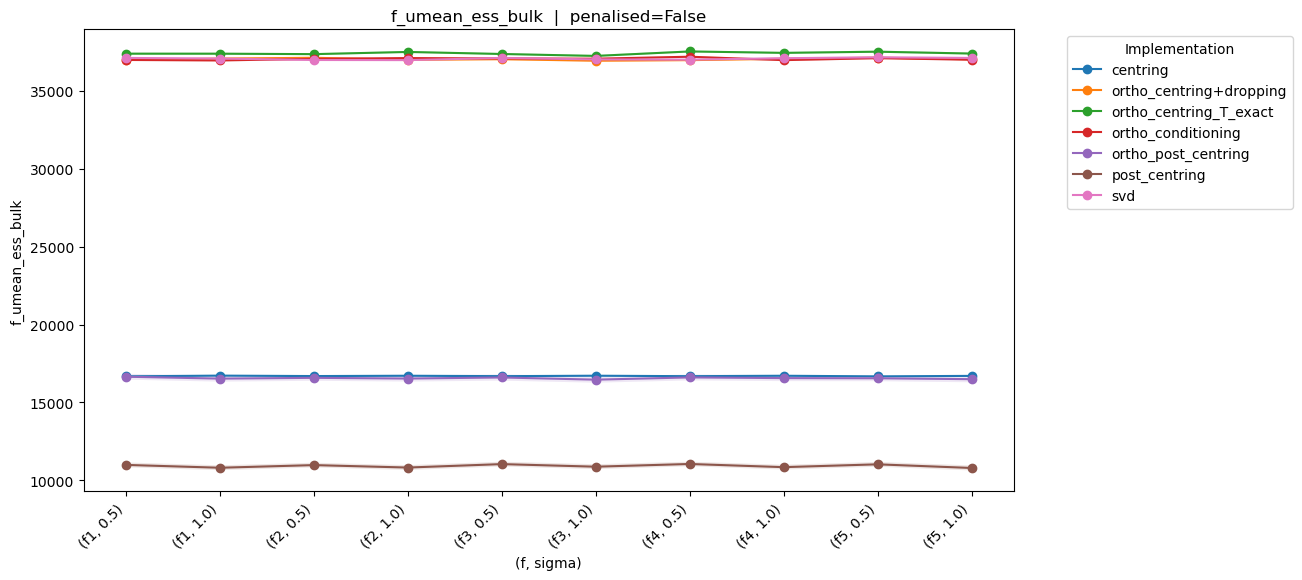

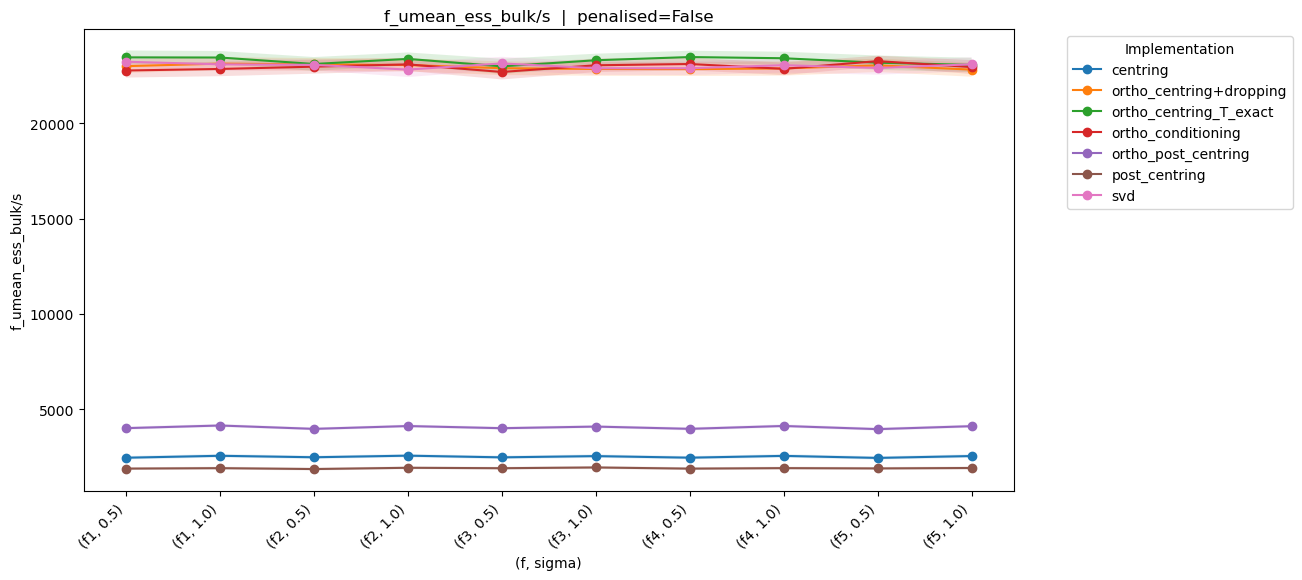

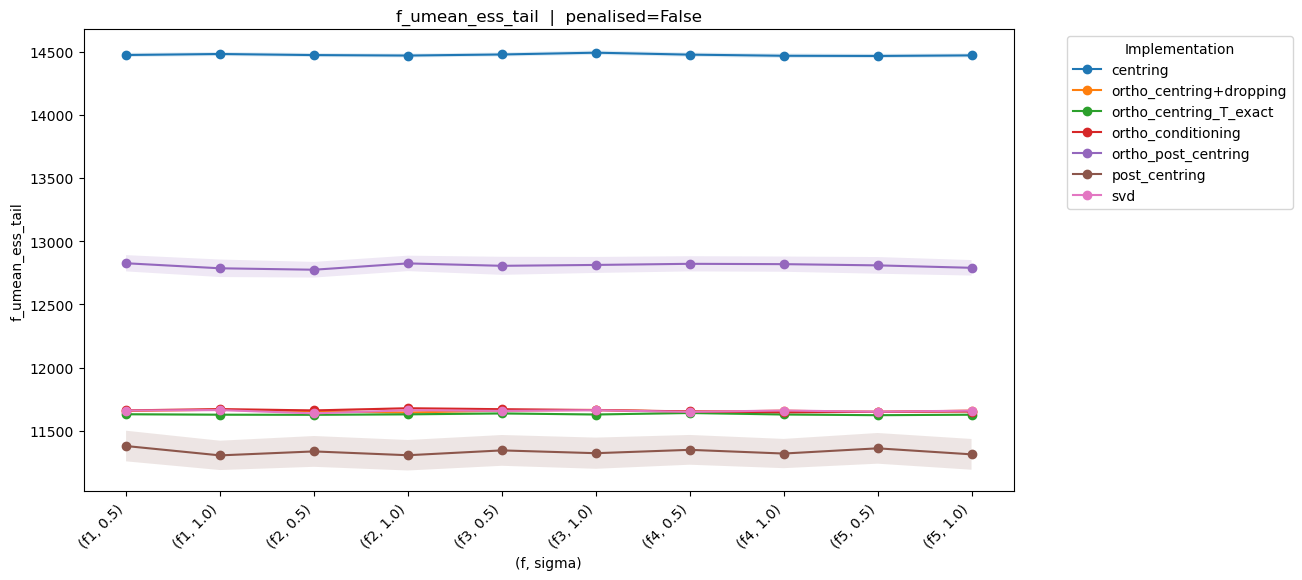

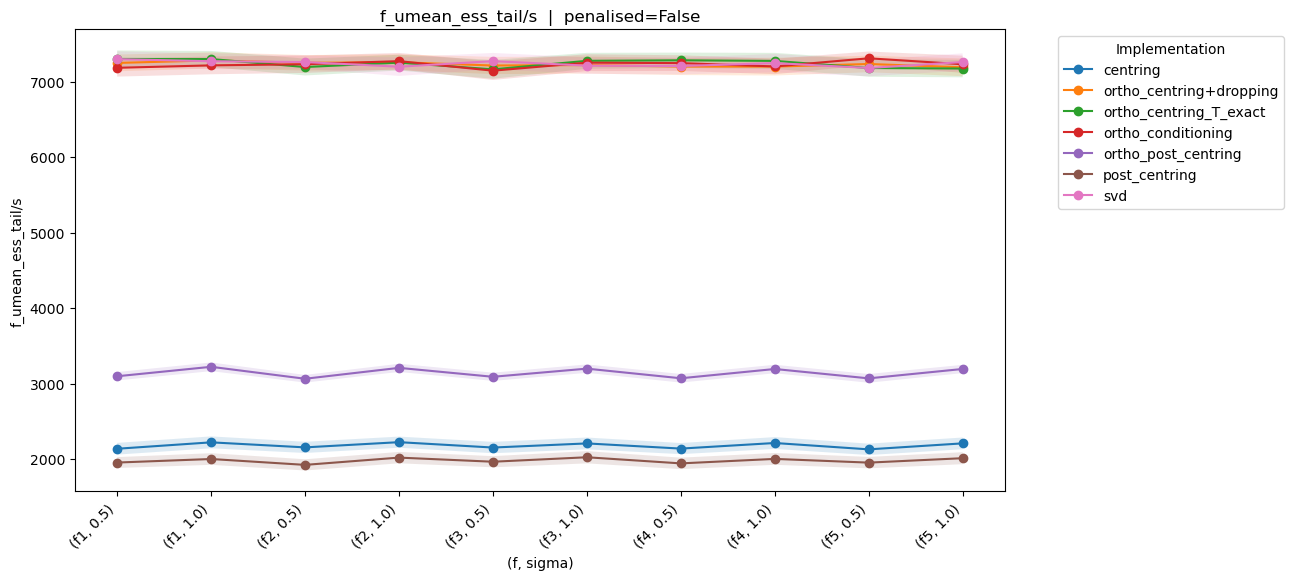

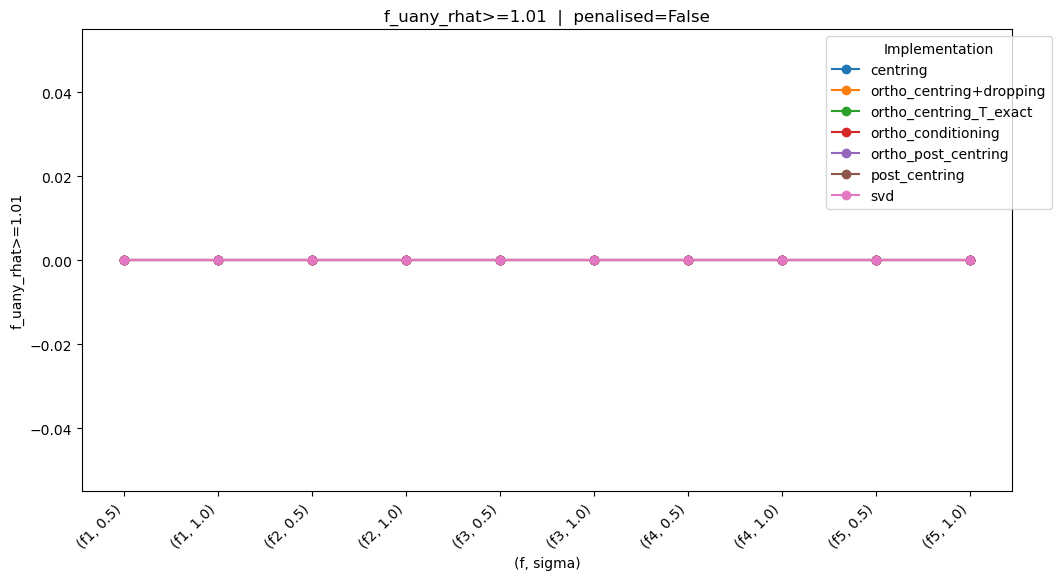

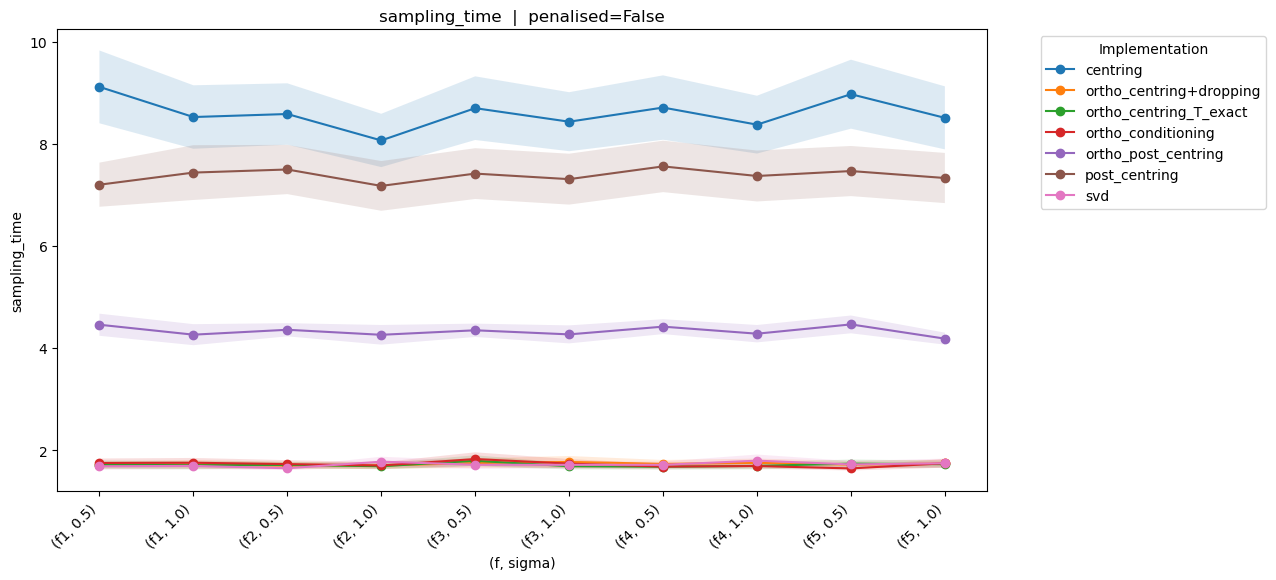

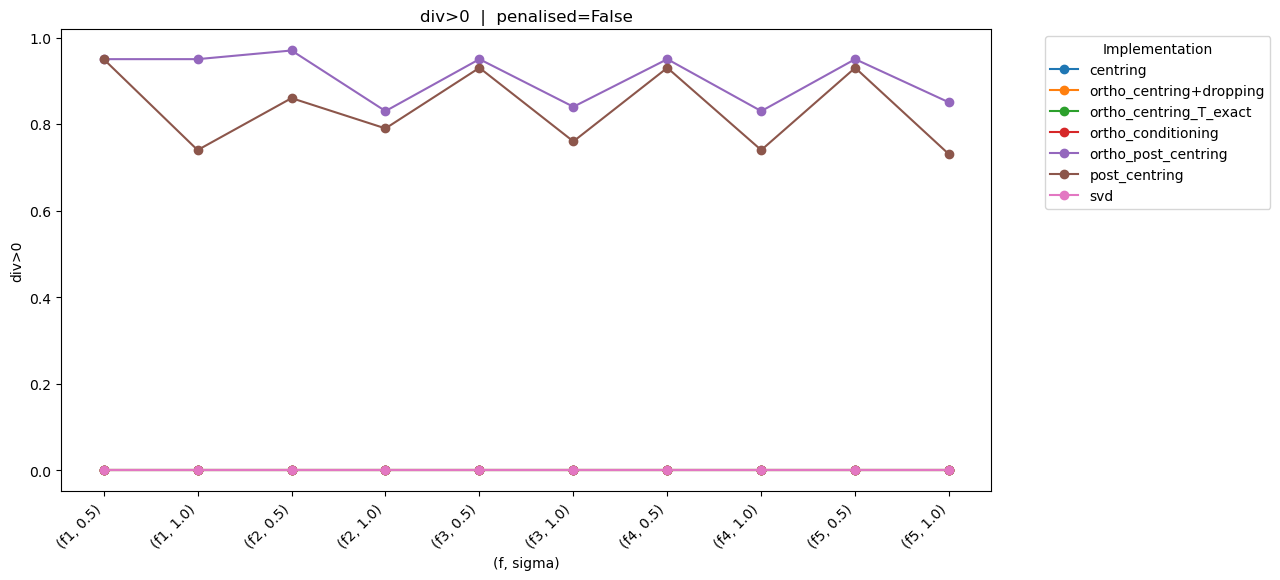

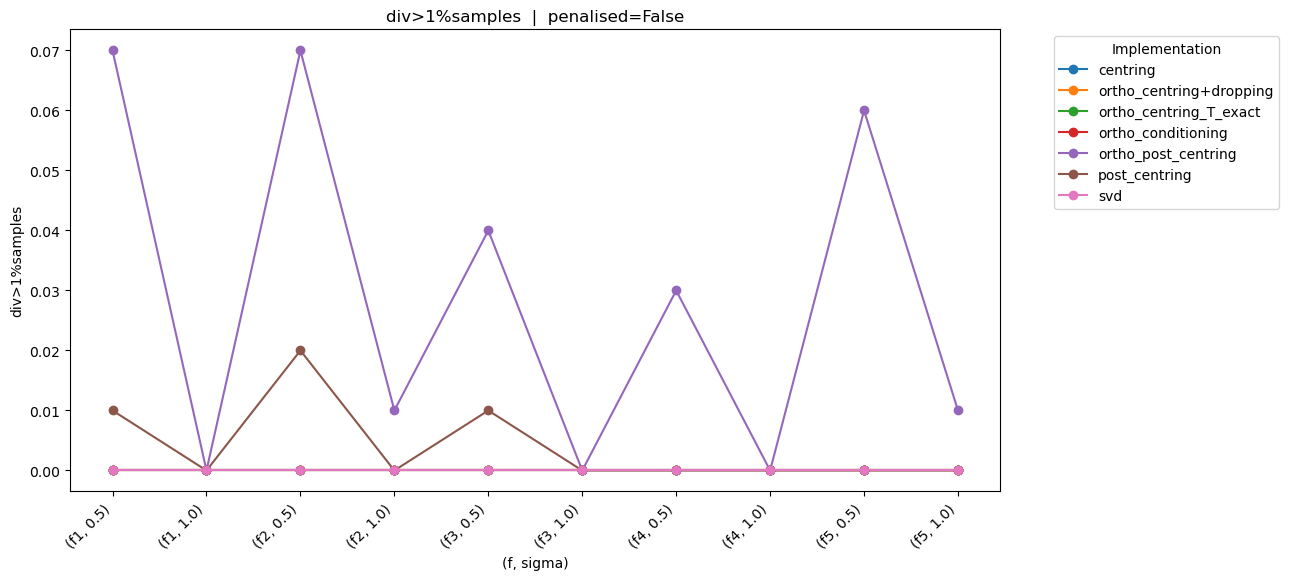

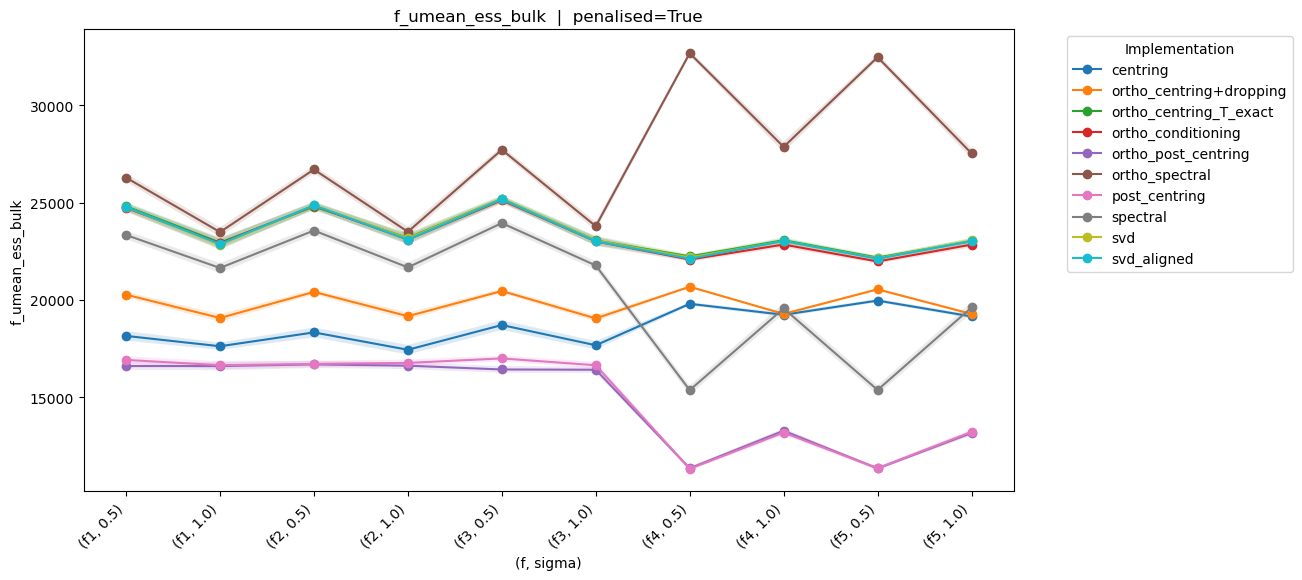

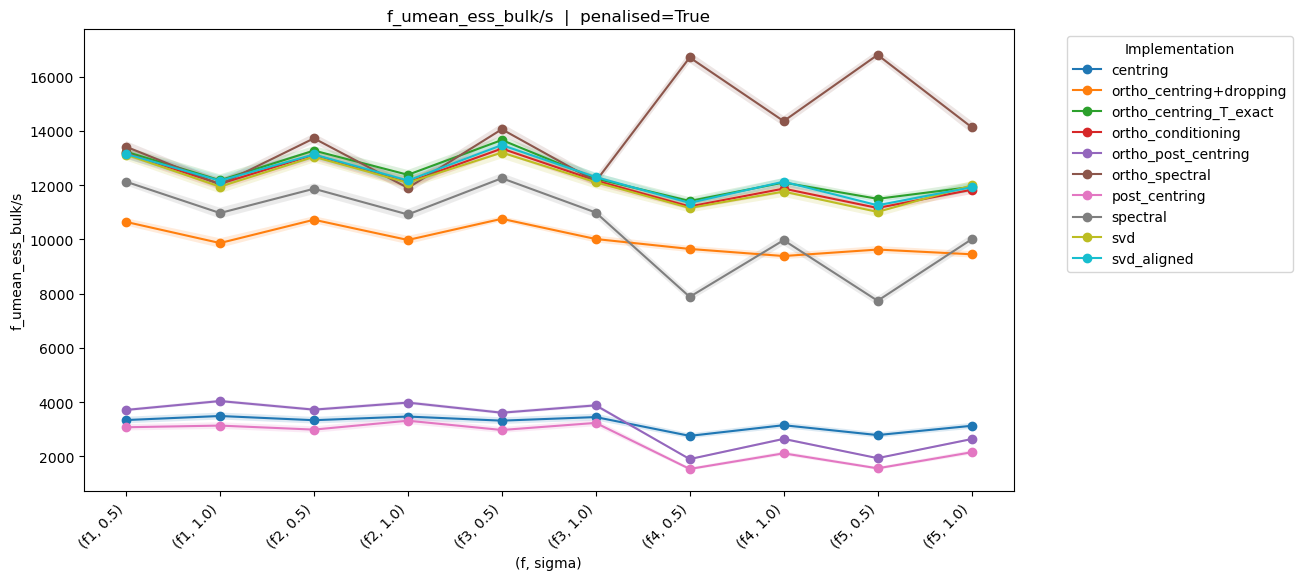

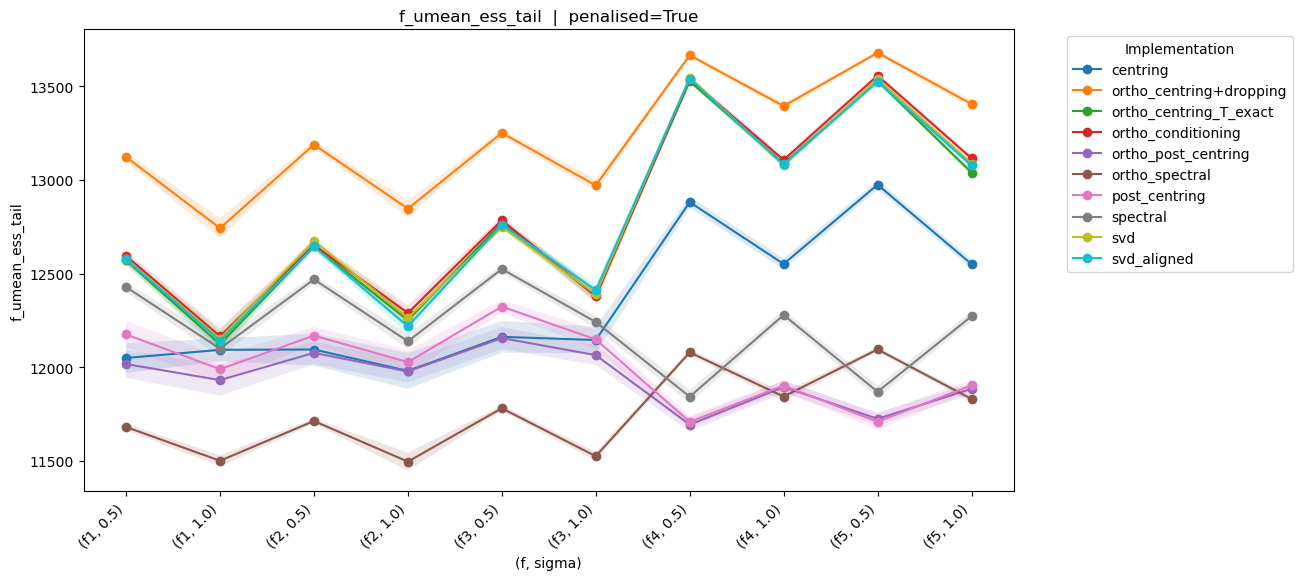

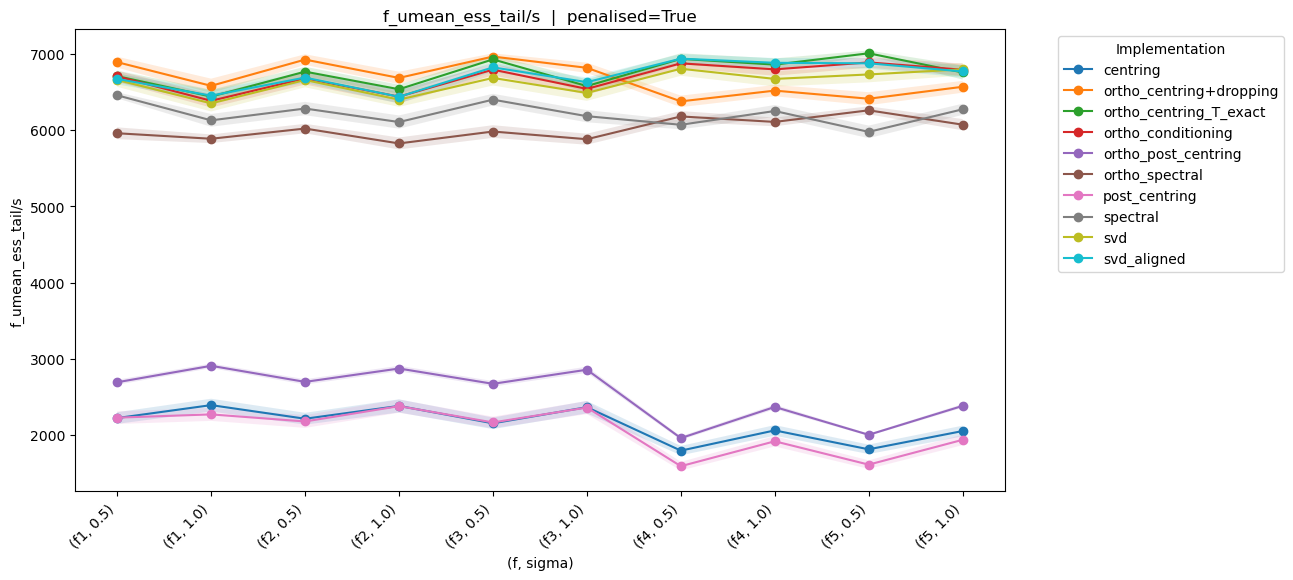

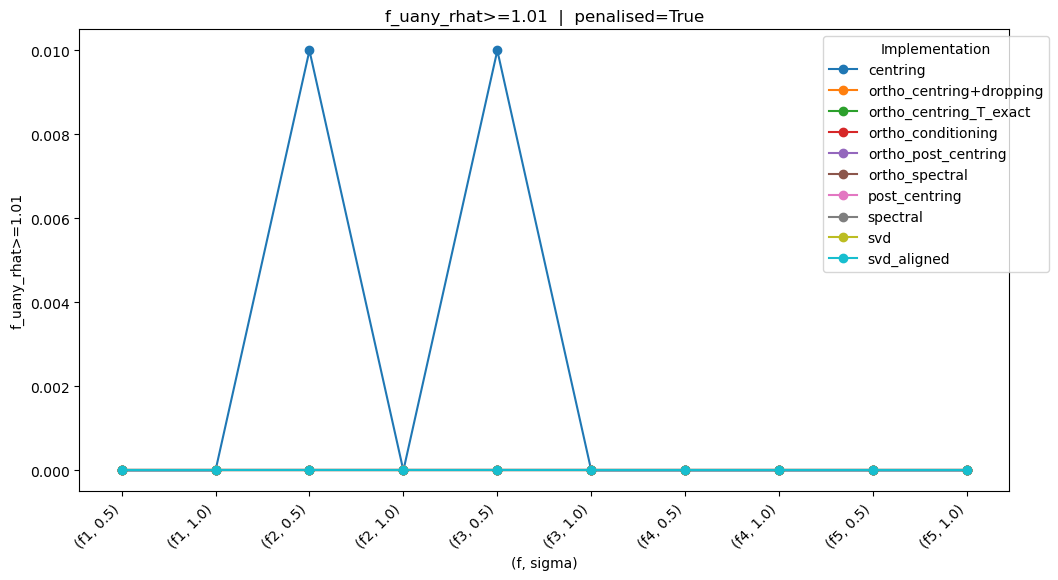

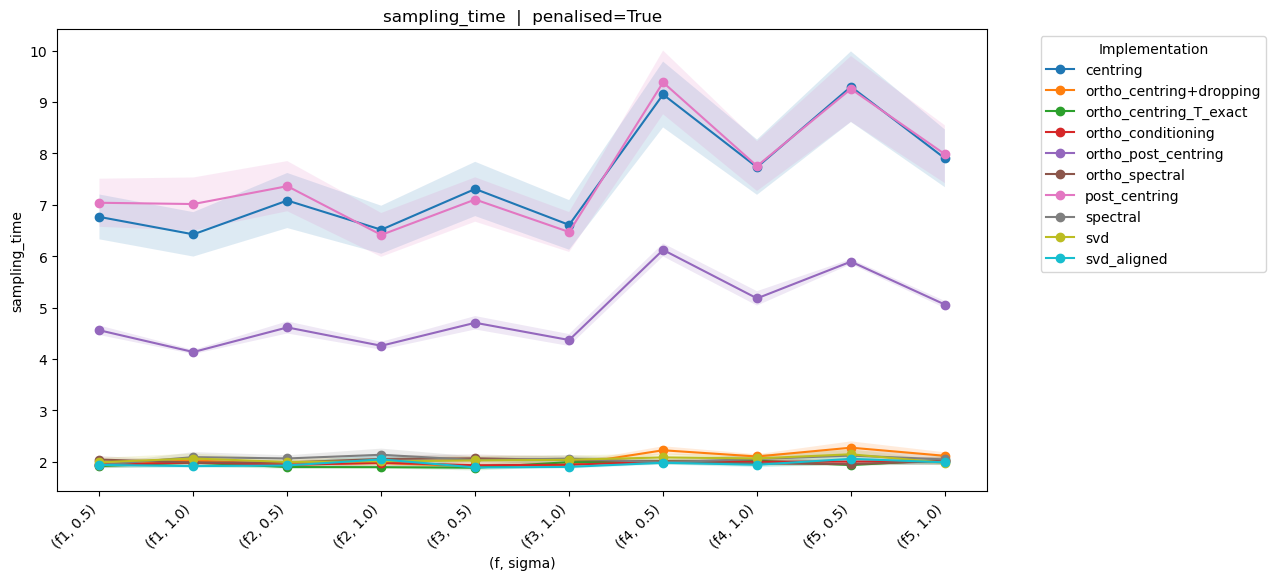

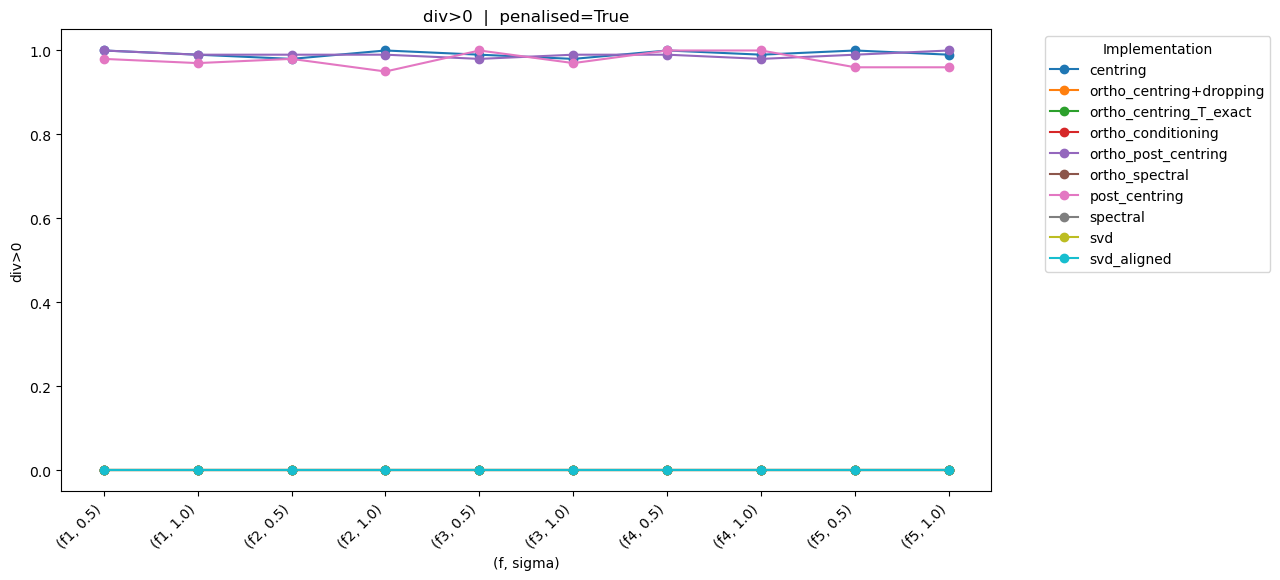

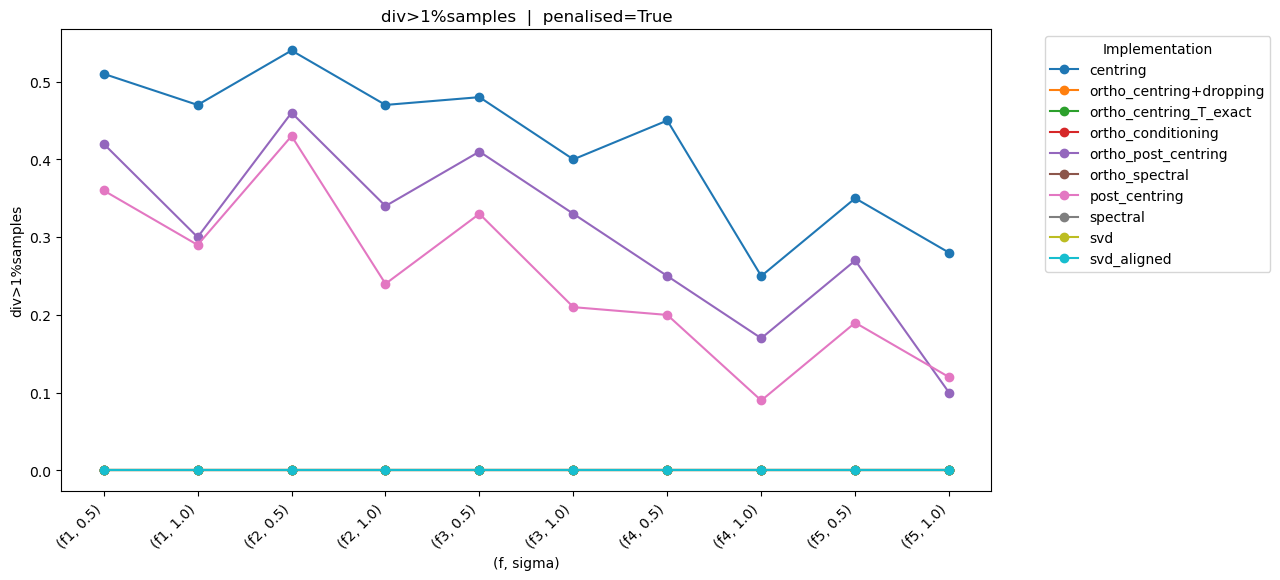

In [88]:
for penalised in sorted(tasks_df['penalised'].unique()):

    current_df = tasks_df[tasks_df['penalised'] == penalised].copy()

    # Define task ordering once
    tasks = (
        current_df[['f', 'sigma']]
        .drop_duplicates()
        .sort_values(['f', 'sigma'])
    )

    task_labels = [
        f"({f}, {sigma})"
        for f, sigma in zip(tasks['f'], tasks['sigma'])
    ]

    x = np.arange(len(tasks))

    for metric, val_col, sd_col in zip(
        metric_list['metric'],
        metric_list['val_col'],
        metric_list['sd_col']
    ):

        fig, ax = plt.subplots(figsize=(12, 6))

        for implementation in sorted(current_df['Implementation'].unique()):

            impl_df = current_df[
                current_df['Implementation'] == implementation
            ]

            # align to task order
            plot_df = tasks.merge(
                impl_df,
                on=['f', 'sigma'],
                how='left'
            )

            y = plot_df[val_col].astype(float).values

            if sd_col is not None:
                se = (
                    plot_df[sd_col].astype(float).values
                    / np.sqrt(plot_df['n_replications'].astype(float).values)
                )
            else:
                se = np.zeros_like(y)

            ax.plot(x, y, marker='o', label=implementation)

            if sd_col is not None:
                ax.fill_between(
                    x,
                    y - se,
                    y + se,
                    alpha=0.15
                )

        ax.set_xticks(x)
        ax.set_xticklabels(task_labels, rotation=45, ha='right')

        ax.set_xlabel("(f, sigma)")
        ax.set_ylabel(metric)
        ax.set_title(
            f"{metric}  |  penalised={penalised}"
        )

        ax.legend(
            title="Implementation",
            bbox_to_anchor=(1.05, 1)
        )
        #plt.tight_layout()
        plt.show()

In [80]:
for penalised in tasks_df['penalised'].unique():
    current_df = tasks_df[tasks_df['penalised'] == penalised]
    implementations = current_df['Implementation'].unique()
    for i in range(len(metric_list['metric'])):
        metric = metric_list['metric'][i]
        val_col = metric_list['val_col'][i]
        sd_col = metric_list['sd_col'][i]

        metric_list['val_curve'].append({})
        metric_list['sd_curve'].append({})

        for implementation in implementations:
            a = current_df[current_df['Implementation'] == implementation][val_col].values
            a = a.astype(float)
            b = current_df[current_df['Implementation'] == implementation]['n_replications'].values
            b = b.astype(float)
            if sd_col is not None:
                c = current_df[current_df['Implementation'] == implementation][sd_col].values
                c = c.astype(float)
                c /= np.sqrt(b)
            else:
                c = np.zeros(len(a))
                
            metric_list['val_curve'][-1][implementation] = a
            metric_list['sd_curve'][-1][implementation] = c

In [ ]:
for penalised in tasks_df['penalised'].unique():
    implementations = current_df['Implementation'].unique()
    for i in range(len(metric_list['metric'])):
        fig = plt.figure(figsize=(10, 6))

        metric = metric_list['metric'][i]
        val_col = metric_list['val_col'][i]
        sd_col = metric_list['sd_col'][i]

        

In [51]:
tasks_df.columns

Index(['f', 'sigma', 'penalised', 'Implementation',
       'f (summary) umean_ess_bulk_rmean', 'f (summary) umean_ess_bulk_rsd',
       'f (summary) umean_ess_bulk/s_rmean',
       'f (summary) umean_ess_bulk/s_rsd', 'f (summary) umean_ess_tail_rmean',
       'f (summary) umean_ess_tail_rsd', 'f (summary) umean_ess_tail/s_rmean',
       'f (summary) umean_ess_tail/s_rsd',
       'f (summary) umean_r_hat>=1.01_rmean',
       'f (summary) uany_r_hat>=1.01_rmean', 'Implementation_',
       'w (summary) umean_ess_bulk/s_rmean',
       'w (summary) umean_ess_bulk/s_rsd', 'w (summary) umean_ess_bulk_rmean',
       'w (summary) umean_ess_bulk_rsd', 'w (summary) umean_ess_tail/s_rmean',
       'w (summary) umean_ess_tail/s_rsd', 'w (summary) umean_ess_tail_rmean',
       'w (summary) umean_ess_tail_rsd', 'w (summary) umean_r_hat>=1.01_rmean',
       'w (summary) uany_r_hat>=1.01_rmean', 'other_bad_rhat',
       'sampling_time_rmean', 'sampling_time_rsd', 'n_replications',
       'div>0_rmean',

In [47]:
b

<xarray.DataArray (implementation: 7, metric: 29)> Size: 2kB
array([['ortho_centring_T_exact', 23722.7806057101, 463.66215061707845,
        15181.54543968497, 2567.2276850821822, 12372.315168181543,
        117.45587503245596, 7914.357123268536, 1323.124440453833, 0.0,
        0.0, 'ortho_centring_T_exact', 15147.67792075455,
        2560.6031680143947, 23671.18333333333, 461.7831740608129,
        7913.488916411906, 1329.6326729748855, 12368.55888888889,
        146.05639994261648, 0.0, 0.0, '{}', 1.6743731164932252,
        0.6795204013502291, 100, 0.0, 0.0, 0.0],
       ['ortho_centring+dropping', 22751.48346682333, 372.3776050496008,
        14807.859839432873, 2155.595417462621, 12453.359103761512,
        114.4974872616096, 8107.239127270544, 1180.9649676445645, 0.0,
        0.0, 'ortho_centring+dropping', 14803.46978154292,
        2148.41487850924, 22746.93, 369.9869428946108, 8127.035597005498,
        1183.2045495689151, 12483.31375, 133.19581390639686, 0.0, 0.0,
        '{}', 1.6468606519699096, 0.8306140516060357, 100, 0.0, 0.0, 0.0],
       ['svd', 22743.501788314785, 431.0981217436372, 14747.742667064236,
        2308.6973491781787, 12461.147820039469, 113.71792697675971,
        8075.98171522244, 1248.0299485919456, 0.0, 0.0, 'svd',
        14752.087803734406, 2303.405505064006, 22753.64625,
        410.9421568386328, 8083.067405324779, 1247.1066568745853,
...
        16618.116666666672, 418.3542820120022, 1446.6897000169945,
        563.9201981921797, 11660.046666666669, 252.2231469292888, 0.0,
        0.0, '{}', 10.373907792568207, 6.424953639707035, 100, 0.27,
        6.3125e-05, 0.0],
       ['ortho_post_centring', 15732.298205181109, 1422.7015266549906,
        3099.7895399314207, 572.0618567544584, 11062.842157685887,
        490.617451031609, 2180.958530464763, 377.5340325893955, 0.0, 0.0,
        'ortho_post_centring', 3153.1528409263265, 559.3346880822022,
        15985.366666666663, 833.9349087160872, 2197.023485391943,
        380.5026837691252, 11133.998888888887, 323.7699070556354, 0.0,
        0.0, '{}', 5.48374639749527, 2.6548993209397933, 100, 0.97,
        0.002630625, 0.07],
       ['post_centring', 12487.955027824377, 476.3711030389882,
        1771.8638993296531, 667.2327717609436, 9846.571596842066,
        468.3529157636761, 1399.4468743741934, 532.6750877584511, 0.0,
        0.0, 'post_centring', 1840.5835028099768, 692.5969700279755,
        12968.16666666667, 374.54321430606126, 1484.6490130151592,
        563.6865259055668, 10440.35, 333.4777840250705, 0.0, 0.0, '{}',
        9.464763884544372, 6.97852911775297, 100, 0.89,
        0.0010118749999999, 0.0]], dtype=object)
Coordinates:
  * implementation  (implementation) int64 56B 0 1 2 3 4 5 6
  * metric          (metric) object 232B 'Implementation' ... 'div>1%samples_...

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
def f1(x):
    return 2 * (x/6) + 6.0
def f2(x):
    return 1 * (x**2/9-1/2) - 1.5
def f3(x):
    return (-3) * (np.sin(x)/2) + 0.0

def f4(x):
    spline_degree = 3
    n_internal_knots = 5
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x), np.max(x), n_internal_knots, x)
    B = eval_B['B']
    c = B[:, -1]
    c = c/(np.max(c) - np.min(c))*5.0
    return c

def f5(x):
    spline_degree = 3
    n_internal_knots = 5
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x), np.max(x), n_internal_knots, x)
    B = eval_B['B']
    c = B[:, 0]
    c = c/(np.max(c) - np.min(c))*5.0
    return c

In [51]:
x = np.linspace(-3, 3, 100)

In [52]:
np.std(f1(x)), np.mean(f1(x)), np.std(f2(x)), np.mean(f2(x)), np.std(f3(x)), np.mean(f3(x))

(np.float64(0.5831529302570124),
 np.float64(6.000000000000001),
 np.float64(0.304119842919887),
 np.float64(-1.65993265993266),
 np.float64(1.0798152930248317),
 np.float64(8.326672684688674e-18))

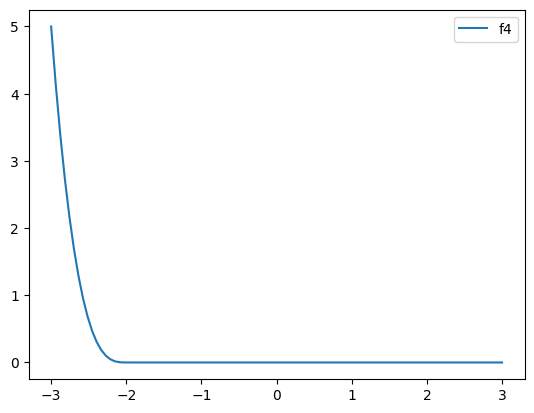

In [58]:
plt.plot(x, f5(x), label='f4')
plt.legend()
plt.show()

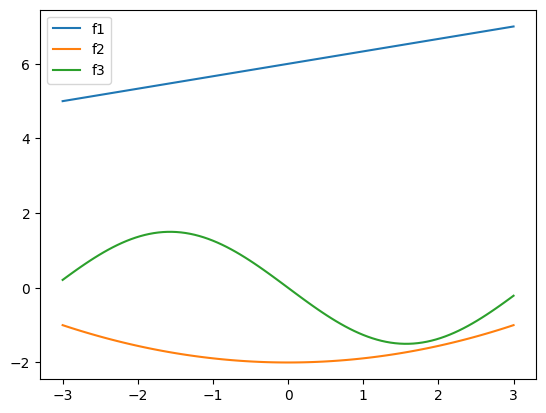

In [53]:
plt.plot(x, f1(x), label='f1')
plt.plot(x, f2(x), label='f2')
plt.plot(x, f3(x), label='f3')
plt.legend()
plt.show()

In [1]:
from _utils_models import *
import pickle
import matplotlib.pyplot as plt

In [2]:
data = pickle.load(open('data.pkl', 'rb'))

In [3]:
data = data[('f1', 0.33)]

In [4]:
x_data, y_data = data[22]
x_order = np.argsort(x_data)

In [5]:
a = 1
b = 0.005
spline_degree = 3
n_internal_knots = 5
penalised=True
order = 2

In [82]:
implementation = 'ortho_centring_T'
K_oc, K_V_oc, K_U_oc, Q_oc, X_oc, X_plot_oc = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [83]:
K_oc.shape, K_V_oc.shape, K_U_oc.shape, X_oc.shape, X_plot_oc.shape

((9, 9), (9,), (9, 9), (100, 9), (500, 9))

In [84]:
implementation = 'svd'
K_svd, K_V_svd, K_U_svd, Q_svd, X_svd, X_plot_svd = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [85]:
K_svd.shape, K_V_svd.shape, K_U_svd.shape, X_svd.shape, X_plot_svd.shape

((8, 8), (8,), (8, 8), (100, 8), (500, 8))

In [86]:
k = K_oc.shape[0]
e_k = np.zeros(k)
e_k[-1] = 1
l = np.argmax(np.abs(K_U_oc.T @ e_k))
print(l)
new_order = np.arange(k)
new_order[l:] = np.arange(l+1, k+1)
new_order[-1] = l
print(new_order)


1
[0 2 3 4 5 6 7 8 1]


In [87]:
K_U_oc = K_U_oc[:, new_order]

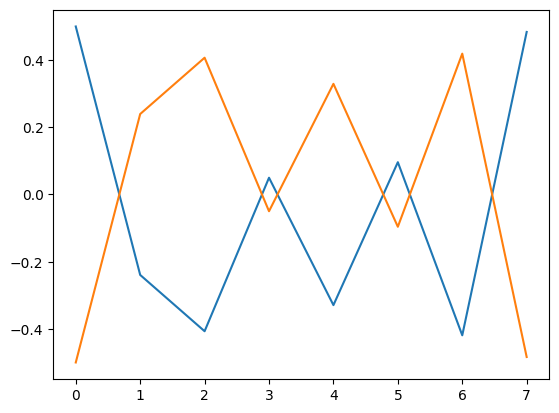

In [102]:
i = 0
plt.plot(K_U_oc[:-1, i])
plt.plot(K_U_svd[:, i])
plt.show()

In [31]:
K_V_oc.sort()
K_V_svd

array([2.73171032e-15, 7.71665843e-02, 5.57231707e-01, 1.93386855e+00,
       4.51280098e+00, 8.10273179e+00, 1.19299673e+01, 1.48862331e+01])

In [ ]:
[]

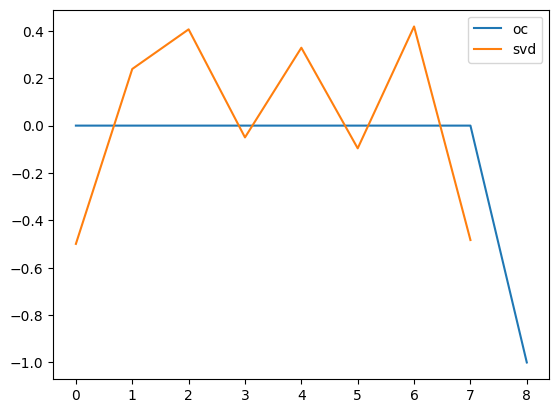

In [67]:
i = 0
plt.plot(K_U_oc[:, i+1], label='oc')
plt.plot(K_U_svd[:, i], label='svd')
plt.legend()
plt.show()

In [60]:
a = 1
b = 0.005
spline_degree = 3
n_internal_knots = 20
penalised=True
order = 2

In [61]:
implementation = 'ortho_centring'
U_oc, S_oc, Vt_oc, X_oc, X_plot_oc = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [62]:
implementation = 'svd'
U_svd, S_svd, Vt_svd, Up_svd, Sp_svd, Vp_svd, X_svd, X_plot_svd = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [63]:
Vt_oc.T[:, -1]

array([0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415])

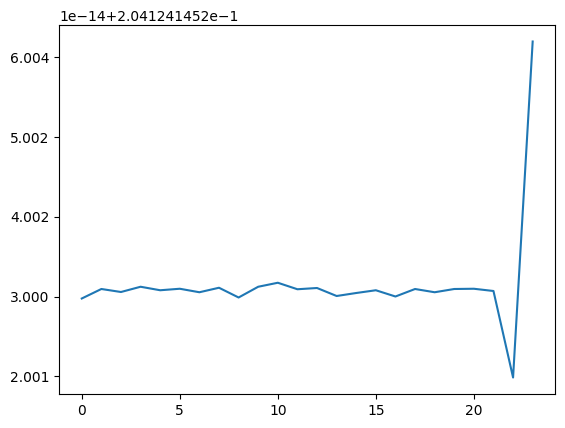

In [64]:
plt.plot(Vt_oc.T[:, -1])

In [65]:
S_svd

array([2.44564793e+00, 2.33717742e+00, 2.21926388e+00, 1.97603849e+00,
       1.82694152e+00, 1.67463028e+00, 1.57893604e+00, 1.55848429e+00,
       1.45436651e+00, 1.38187140e+00, 1.27785229e+00, 1.10090591e+00,
       1.03540801e+00, 9.53429155e-01, 8.36203756e-01, 7.97395152e-01,
       6.62531750e-01, 5.58019057e-01, 5.34289824e-01, 4.42374304e-01,
       3.42726129e-01, 6.95742341e-02, 6.36249240e-02, 3.13017399e-15])

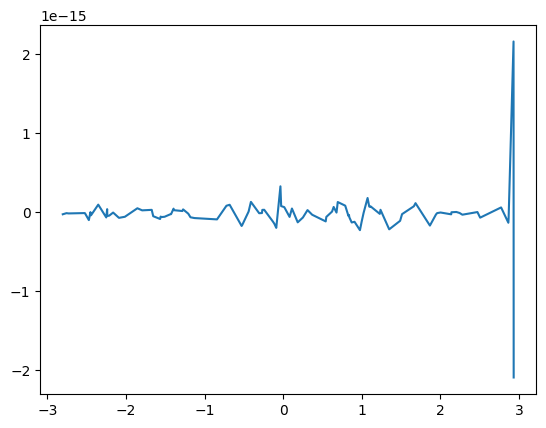

In [66]:
i = -1
plt.plot(x_data[x_order], ((U_oc * S_oc))[x_order, i])
#plt.plot(x_data[x_order], ((Up_svd * Sp_svd))[x_order, i])
plt.show()

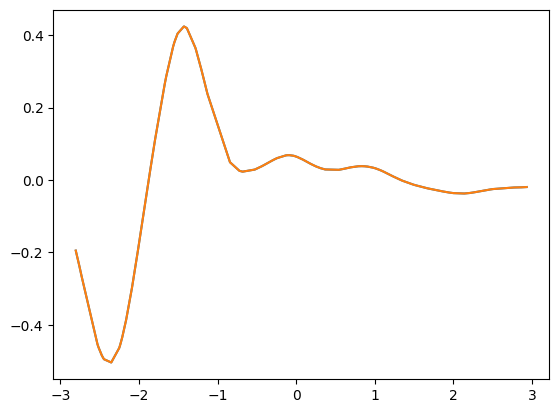

In [67]:
i = 2
plt.plot(x_data[x_order], ((X_oc))[x_order, i])
plt.plot(x_data[x_order], ((X_svd))[x_order, i])
plt.show()

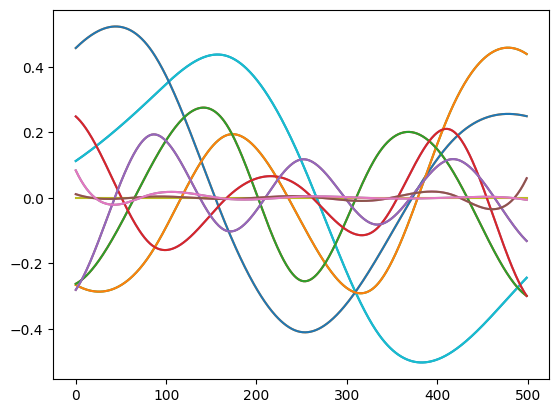

In [46]:
plt.plot(X_plot_oc)
plt.plot(X_plot_svd)
plt.show()

In [48]:
np.sum(X_oc[:, :-1]-X_svd)

np.float64(0.0)

In [30]:
implementation = 'svd'
model, X_svd, X_plot_svd, var_names = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)
    

In [31]:
implementation = 'ortho_centring'
model, X_oc, X_plot_oc, var_names = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)
    

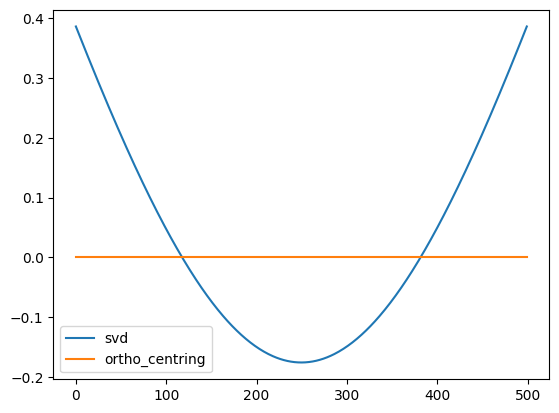

In [46]:
i = 1
plt.plot(X_plot_svd[:, i], label='svd')
plt.plot(X_plot_oc[:, i], label='ortho_centring')
plt.legend()
plt.show()

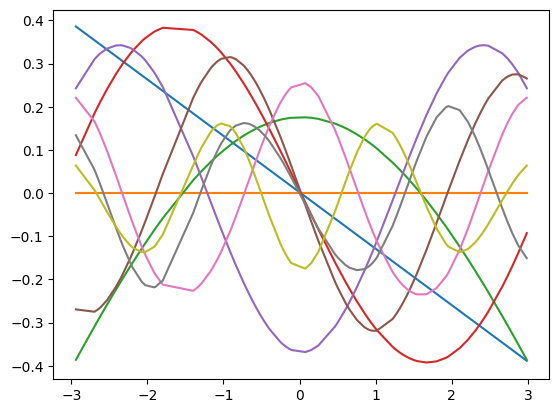

In [29]:
plt.plot(x_data[x_order], X[x_order])
plt.show()